In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Zoek automatisch de map met check-in bestanden
possible_dirs = [Path('Check-in times'), Path('Data-main') / 'Check-in times']
checkin_dir = None
for d in possible_dirs:
    if d.exists():
        checkin_dir = d
        break

if checkin_dir is None:
    matches = list(Path('.').rglob('Check-in times'))
    if matches:
        checkin_dir = matches[0]

if checkin_dir is None:
    raise FileNotFoundError('Map met check-in bestanden niet gevonden. Zet het notebook in de Data-main map of naast de Data-main map.')

checkin_files = sorted(checkin_dir.glob('Check-in-times*.csv'))
if len(checkin_files) == 0:
    raise FileNotFoundError(f'Geen check-in CSV-bestanden gevonden in {checkin_dir}')

print('Gevonden check-in bestanden:')
for file in checkin_files:
    print('-', file.name)

# Inladen en kolomnamen per bestand opschonen voordat alles wordt samengevoegd.
# Dit voorkomt dubbele kolommen door bijvoorbeeld 'Lid id ' versus 'Lid id'.
dfs = []
for file in checkin_files:
    df_temp = pd.read_csv(file, decimal='.')
    df_temp.columns = (
        df_temp.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_', regex=False)
    )
    df_temp['bronbestand'] = file.name
    dfs.append(df_temp)

df_checkin = pd.concat(dfs, ignore_index=True)

# Datum omzetten
df_checkin['incheckdatum'] = pd.to_datetime(df_checkin['incheckdatum'], errors='coerce')
df_checkin = df_checkin.dropna(subset=['incheckdatum']).copy()

# Tekstkolommen opschonen
for col in ['lid_id', 'geslacht', 'abo_bezoek']:
    if col in df_checkin.columns:
        df_checkin[col] = df_checkin[col].astype(str).str.strip()

# Lid id iets netter categoriseren, zodat visualisaties beter leesbaar zijn
def categoriseer_lid_id(value):
    value = str(value).strip().lower()
    if 'rug' in value and 'medewerker' in value:
        return 'Medewerker RUG'
    elif 'hanze' in value and 'medewerker' in value:
        return 'Medewerker Hanze'
    elif 'rug' in value:
        return 'Student RUG'
    elif 'hanze' in value:
        return 'Student Hanze'
    elif value in ['nan', '', 'none']:
        return 'Onbekend'
    else:
        return 'Overig/onbekend'

df_checkin['instelling_categorie'] = df_checkin['lid_id'].apply(categoriseer_lid_id)

print('Aantal check-ins totaal:', len(df_checkin))
print('Kolommen:', df_checkin.columns.tolist())
df_checkin.head()

Gevonden check-in bestanden:
- Check-in-times_sheet_2017-2018.csv
- Check-in-times_sheet_2018-2019.csv
- Check-in-times_sheet_2019-2020.csv
- Check-in-times_sheet_2020-2021.csv
- Check-in-times_sheet_2021- .csv


Aantal check-ins totaal: 380785
Kolommen: ['klant_nr', 'lid_id', 'geslacht', 'abo_bezoek', 'incheckdatum', 'bronbestand', 'instelling_categorie']


,klant_nr,lid_id,geslacht,abo_bezoek,incheckdatum,bronbestand,instelling_categorie
0,168236,Medewerker RUG,M,Fitness Card 2016-2017,2017-08-01 12:49:10,Check-in-times_sheet_2017-2018.csv,Medewerker RUG
1,132339,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:11,Check-in-times_sheet_2017-2018.csv,Student RUG
2,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:34,Check-in-times_sheet_2017-2018.csv,Student RUG
3,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:54:13,Check-in-times_sheet_2017-2018.csv,Student RUG
4,186817,RUG,M,Fitness Card 2016-2017,2017-08-01 13:00:58,Check-in-times_sheet_2017-2018.csv,Student RUG


In [2]:
# Mogelijke dubbele check-ins markeren
# Uitgangspunt: dezelfde klant binnen 60 seconden opnieuw = waarschijnlijk dubbele registratie.
# We verwijderen ze niet uit df_checkin zelf, maar maken een opgeschoonde analyseversie.

df_checkin = df_checkin.sort_values(['klant_nr', 'incheckdatum']).copy()
df_checkin['vorige_checkin'] = df_checkin.groupby('klant_nr')['incheckdatum'].shift(1)
df_checkin['verschil_seconden'] = (df_checkin['incheckdatum'] - df_checkin['vorige_checkin']).dt.total_seconds()
df_checkin['mogelijk_duplicaat_60s'] = df_checkin['verschil_seconden'].between(0, 60, inclusive='both')

print('Aantal check-ins totaal:', len(df_checkin))
print('Aantal mogelijke dubbele check-ins binnen 60 seconden:', int(df_checkin['mogelijk_duplicaat_60s'].sum()))
print('Percentage mogelijke dubbelen:', round(df_checkin['mogelijk_duplicaat_60s'].mean() * 100, 2), '%')

# Dataset voor analyse zonder mogelijke dubbelen
df_checkin_clean = df_checkin[~df_checkin['mogelijk_duplicaat_60s']].copy()
print('Aantal check-ins na verwijderen mogelijke dubbelen:', len(df_checkin_clean))

Aantal check-ins totaal: 380785
Aantal mogelijke dubbele check-ins binnen 60 seconden: 44023
Percentage mogelijke dubbelen: 11.56 %
Aantal check-ins na verwijderen mogelijke dubbelen: 336762


In [3]:
# Dagtabel maken: dit is de basis voor visualisaties, correlaties en modellering.
# De afhankelijke variabele wordt: aantal_bezoeken per dag.

df_checkin_clean['datum'] = df_checkin_clean['incheckdatum'].dt.floor('D')

df_checkin_per_dag = (
    df_checkin_clean
    .groupby('datum')
    .agg(
        aantal_bezoeken=('klant_nr', 'size'),
        unieke_bezoekers=('klant_nr', 'nunique')
    )
    .reset_index()
)

# Datumkenmerken toevoegen
df_checkin_per_dag['jaar'] = df_checkin_per_dag['datum'].dt.year
df_checkin_per_dag['maand'] = df_checkin_per_dag['datum'].dt.month
df_checkin_per_dag['week'] = df_checkin_per_dag['datum'].dt.isocalendar().week.astype(int)
df_checkin_per_dag['weekdag_nummer'] = df_checkin_per_dag['datum'].dt.weekday
df_checkin_per_dag['weekdag'] = df_checkin_per_dag['datum'].dt.day_name()
df_checkin_per_dag['is_weekend'] = df_checkin_per_dag['weekdag_nummer'].isin([5, 6]).astype(int)

def bepaal_seizoen(maand):
    if maand in [12, 1, 2]:
        return 'Winter'
    elif maand in [3, 4, 5]:
        return 'Lente'
    elif maand in [6, 7, 8]:
        return 'Zomer'
    else:
        return 'Herfst'

df_checkin_per_dag['seizoen'] = df_checkin_per_dag['maand'].apply(bepaal_seizoen)

# Academic calendar koppelen als het bestand aanwezig is
calendar_file = Path('Academic calendar.xlsx')
if not calendar_file.exists():
    matches = list(Path('.').rglob('Academic calendar.xlsx'))
    calendar_file = matches[0] if matches else None

if calendar_file is not None and Path(calendar_file).exists():
    df_calendar = pd.read_excel(calendar_file)
    df_calendar.columns = (
        df_calendar.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_', regex=False)
    )
    df_calendar['datum'] = pd.to_datetime(df_calendar['datum'], errors='coerce')
    for col in ['feestdag', 'vakantie', 'tentamenperiode', 'weekend']:
        if col in df_calendar.columns:
            df_calendar[col] = df_calendar[col].notna().astype(int)
    df_checkin_per_dag = df_checkin_per_dag.merge(df_calendar, on='datum', how='left')
    for col in ['feestdag', 'vakantie', 'tentamenperiode', 'weekend']:
        if col in df_checkin_per_dag.columns:
            df_checkin_per_dag[col] = df_checkin_per_dag[col].fillna(0).astype(int)
    print('Academic calendar gekoppeld:', calendar_file)
else:
    print('Geen Academic calendar.xlsx gevonden, kalenderkenmerken zijn niet gekoppeld.')

# Opslaan zodat deze tabel later makkelijk gebruikt kan worden voor modellering
df_checkin_per_dag.to_csv('df_checkin_per_dag.csv', index=False)

print('Dagtabel opgeslagen als df_checkin_per_dag.csv')
df_checkin_per_dag.head()

Academic calendar gekoppeld: Academic calendar.xlsx
Dagtabel opgeslagen als df_checkin_per_dag.csv


,datum,aantal_bezoeken,unieke_bezoekers,jaar,maand,week,weekdag_nummer,weekdag,is_weekend,seizoen,feestdag,vakantie,tentamenperiode,weekend
0,2017-08-01,170,137,2017,8,31,1,Tuesday,0,Zomer,0,1,0,0
1,2017-08-02,140,117,2017,8,31,2,Wednesday,0,Zomer,0,1,0,0
2,2017-08-03,146,118,2017,8,31,3,Thursday,0,Zomer,0,1,0,0
3,2017-08-04,157,128,2017,8,31,4,Friday,0,Zomer,0,1,0,0
4,2017-08-07,188,162,2017,8,32,0,Monday,0,Zomer,0,1,0,0


In [4]:
# Beschrijvende statistieken van de dagtabel

print('Eerste datum:', df_checkin_per_dag['datum'].min())
print('Laatste datum:', df_checkin_per_dag['datum'].max())
print('Gemiddeld aantal bezoeken per dag:', round(df_checkin_per_dag['aantal_bezoeken'].mean(), 2))
print('Mediaan aantal bezoeken per dag:', round(df_checkin_per_dag['aantal_bezoeken'].median(), 2))
print('Hoogste aantal bezoeken op één dag:', int(df_checkin_per_dag['aantal_bezoeken'].max()))

print('\nBeschrijvende statistiek aantal bezoeken per dag:')
display(df_checkin_per_dag['aantal_bezoeken'].describe())

print('\nDag met hoogste aantal bezoeken:')
display(df_checkin_per_dag.loc[df_checkin_per_dag['aantal_bezoeken'].idxmax()])

Eerste datum: 2017-08-01 00:00:00
Laatste datum: 2021-12-01 00:00:00
Gemiddeld aantal bezoeken per dag: 266.22
Mediaan aantal bezoeken per dag: 221.0
Hoogste aantal bezoeken op één dag: 645

Beschrijvende statistiek aantal bezoeken per dag:


count    1265.000000
mean      266.215020
std       150.205191
min         1.000000
25%       157.000000
50%       221.000000
75%       395.000000
max       645.000000
Name: aantal_bezoeken, dtype: float64


Dag met hoogste aantal bezoeken:


datum               2018-02-19 00:00:00
aantal_bezoeken                     645
unieke_bezoekers                    439
jaar                               2018
maand                                 2
week                                  8
weekdag_nummer                        0
weekdag                          Monday
is_weekend                            0
seizoen                          Winter
feestdag                              0
vakantie                              0
tentamenperiode                       0
weekend                               0
Name: 193, dtype: object

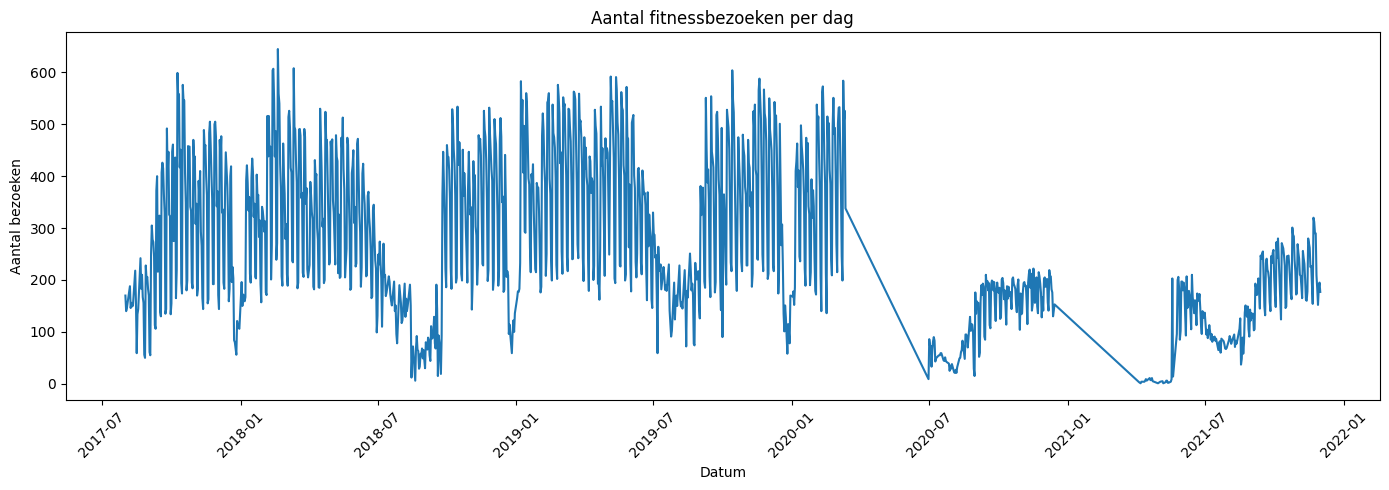

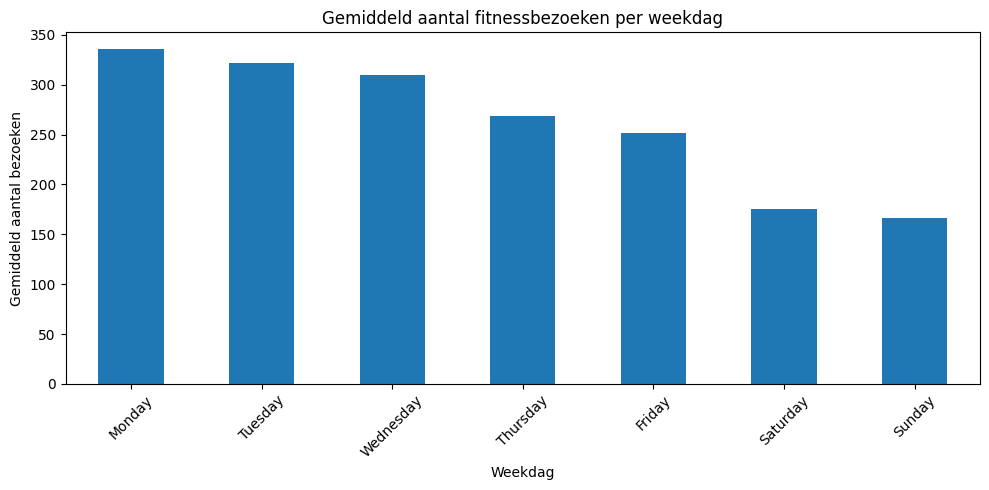

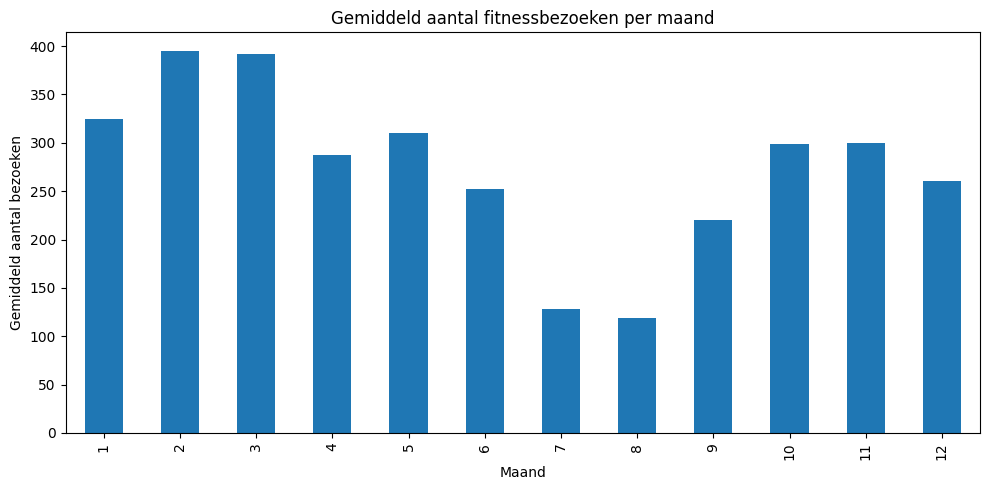

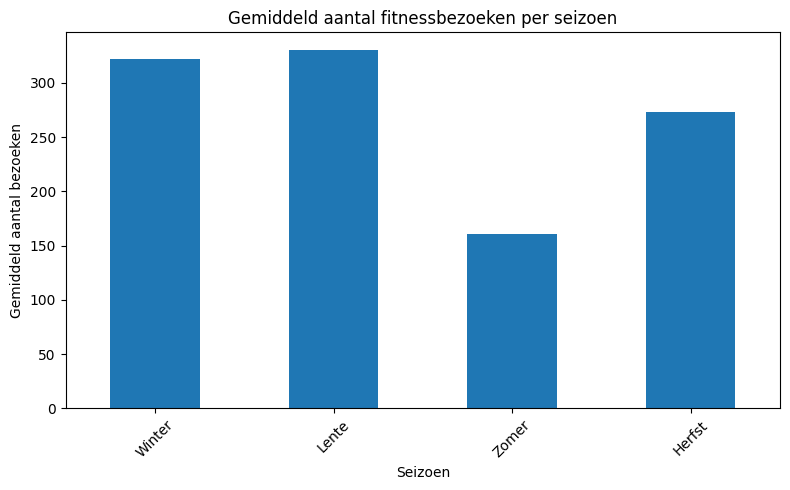

In [5]:
# Basisvisualisaties voor het hoofdstuk Beschrijving van de data / tijdreeksanalyse

# 1. Bezoekers door de tijd
plt.figure(figsize=(14, 5))
plt.plot(df_checkin_per_dag['datum'], df_checkin_per_dag['aantal_bezoeken'])
plt.title('Aantal fitnessbezoeken per dag')
plt.xlabel('Datum')
plt.ylabel('Aantal bezoeken')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Gemiddeld aantal bezoekers per weekdag
weekdag_volgorde = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
gemiddelde_per_weekdag = (
    df_checkin_per_dag
    .groupby('weekdag')['aantal_bezoeken']
    .mean()
    .reindex(weekdag_volgorde)
)

plt.figure(figsize=(10, 5))
gemiddelde_per_weekdag.plot(kind='bar')
plt.title('Gemiddeld aantal fitnessbezoeken per weekdag')
plt.xlabel('Weekdag')
plt.ylabel('Gemiddeld aantal bezoeken')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Gemiddeld aantal bezoekers per maand
gemiddelde_per_maand = df_checkin_per_dag.groupby('maand')['aantal_bezoeken'].mean()

plt.figure(figsize=(10, 5))
gemiddelde_per_maand.plot(kind='bar')
plt.title('Gemiddeld aantal fitnessbezoeken per maand')
plt.xlabel('Maand')
plt.ylabel('Gemiddeld aantal bezoeken')
plt.tight_layout()
plt.show()

# 4. Gemiddeld aantal bezoekers per seizoen
gemiddelde_per_seizoen = df_checkin_per_dag.groupby('seizoen')['aantal_bezoeken'].mean().reindex(['Winter', 'Lente', 'Zomer', 'Herfst'])

plt.figure(figsize=(8, 5))
gemiddelde_per_seizoen.plot(kind='bar')
plt.title('Gemiddeld aantal fitnessbezoeken per seizoen')
plt.xlabel('Seizoen')
plt.ylabel('Gemiddeld aantal bezoeken')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()